In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from util.load import DataLoader

In [2]:
dataloader = DataLoader(data_dir="../data")

In [3]:
max_days = 300
aus_daily_df = dataloader.load_daily_data("kxhighaus", max_days=max_days, type_="processed")
nyc_daily_df = dataloader.load_daily_data("kxhighny",  max_days=max_days, type_="processed")
den_daily_df = dataloader.load_daily_data("kxhighden", max_days=max_days, type_="processed")
lax_daily_df = dataloader.load_daily_data("kxhighlax", max_days=max_days, type_="processed")
mia_daily_df = dataloader.load_daily_data("kxhighmia", max_days=max_days, type_="processed")
chi_daily_df = dataloader.load_daily_data("kxhighchi", max_days=max_days, type_="processed")

Loading kxhighchi for 2025-06-08: 100%|██████████| 297/297 [00:00<00:00, 394.32it/s]


In [4]:
aus_df = dataloader.load_consolidated_daily_data("kxhighaus", max_days=max_days, type_="processed")
nyc_df = dataloader.load_consolidated_daily_data("kxhighny",  max_days=max_days, type_="processed")
den_df = dataloader.load_consolidated_daily_data("kxhighden", max_days=max_days, type_="processed")
lax_df = dataloader.load_consolidated_daily_data("kxhighlax", max_days=max_days, type_="processed")
mia_df = dataloader.load_consolidated_daily_data("kxhighmia", max_days=max_days, type_="processed")
chi_df = dataloader.load_consolidated_daily_data("kxhighchi", max_days=max_days, type_="processed")

Loading kxhighchi for 2025-06-08: 100%|██████████| 297/297 [00:01<00:00, 154.96it/s]


In [5]:
nyc_df.columns

Index(['time', 'trade_id', 'ticker', 'time_to_strike', 'count', 'shift',
       'kalshi_fair', 'forecast', 'yes_price', 'no_price', 'taker_side',
       'kalshi_strike_delta', 'forecast_strike_delta', 'kalshi_forecast_delta',
       'strike_m_3.5', 'strike_m_3.0', 'strike_m_1.0', 'strike_p_1.0',
       'strike_p_3.0', 'strike_p_3.5', 'entropy', 'impact', 'result',
       'outcome'],
      dtype='object')

In [6]:
nyc_df.drop(columns=["time", "ticker", "trade_id"]).head()

,time_to_strike,count,shift,kalshi_fair,forecast,yes_price,no_price,taker_side,kalshi_strike_delta,forecast_strike_delta,...,strike_m_3.5,strike_m_3.0,strike_m_1.0,strike_p_1.0,strike_p_3.0,strike_p_3.5,entropy,impact,result,outcome
0,135720.433,25,1.0,88.5,87.5,38,62,1,0.0,-1.0,...,0.0,0.0,0.0,38.0,0.0,0.0,-138.228,-35.000,-38,0
1,135700.506,11,1.0,88.5,87.5,38,62,1,0.0,-1.0,...,0.0,0.0,0.0,38.0,0.0,0.0,-138.228,-35.097,-38,0
2,135700.506,13,1.0,88.5,87.5,40,60,1,0.0,-1.0,...,0.0,0.0,0.0,40.0,0.0,0.0,-147.555,-37.057,-40,0
3,135608.070,24,1.0,88.5,87.5,39,61,1,0.0,-1.0,...,0.0,0.0,0.0,39.0,0.0,0.0,-142.879,-36.143,-39,0
4,135599.038,24,1.0,88.5,87.5,39,61,1,0.0,-1.0,...,0.0,0.0,0.0,39.0,0.0,0.0,-142.879,-35.544,-39,0


In [48]:
def plot_price_curve(df, ticker, buckets=50):
    df['price_buckets'] = pd.cut(df['yes_price'], buckets)
    outcome_means = df.groupby(['shift', 'price_buckets'])['outcome'].mean()
    shifts = sorted(df['shift'].unique())
    fig, ax = plt.subplots(2, 3, figsize=(13, 7))
    for i, shift in enumerate(shifts):
        shift_data = outcome_means[shift]
        x_values = np.array([(x.left + x.right) / 200 for x in shift_data.index.values])
        if shift < 0:
            ax[0, i].plot(x_values, shift_data, color='blue', label='Signal')
            ax[0, i].plot([0, 1], [0, 1], color='red', linestyle='--', label='True')
            ax[0, i].set_title(f'Shift: {shift}')
        else:
            ax[1, i - 3].plot(x_values, shift_data, color='blue', label='Signal')
            ax[1, i - 3].plot([0, 1], [0, 1], color='red', linestyle='--', label='True')
            ax[1, i - 3].set_title(f'Shift: {shift}')
    ax[0, 0].set_ylabel('Outcome')
    ax[1, 0].set_ylabel('Outcome')
    ax[1, 1].set_xlabel('Price')
    plt.suptitle(ticker)
    plt.legend()
    plt.tight_layout()
    plt.show()

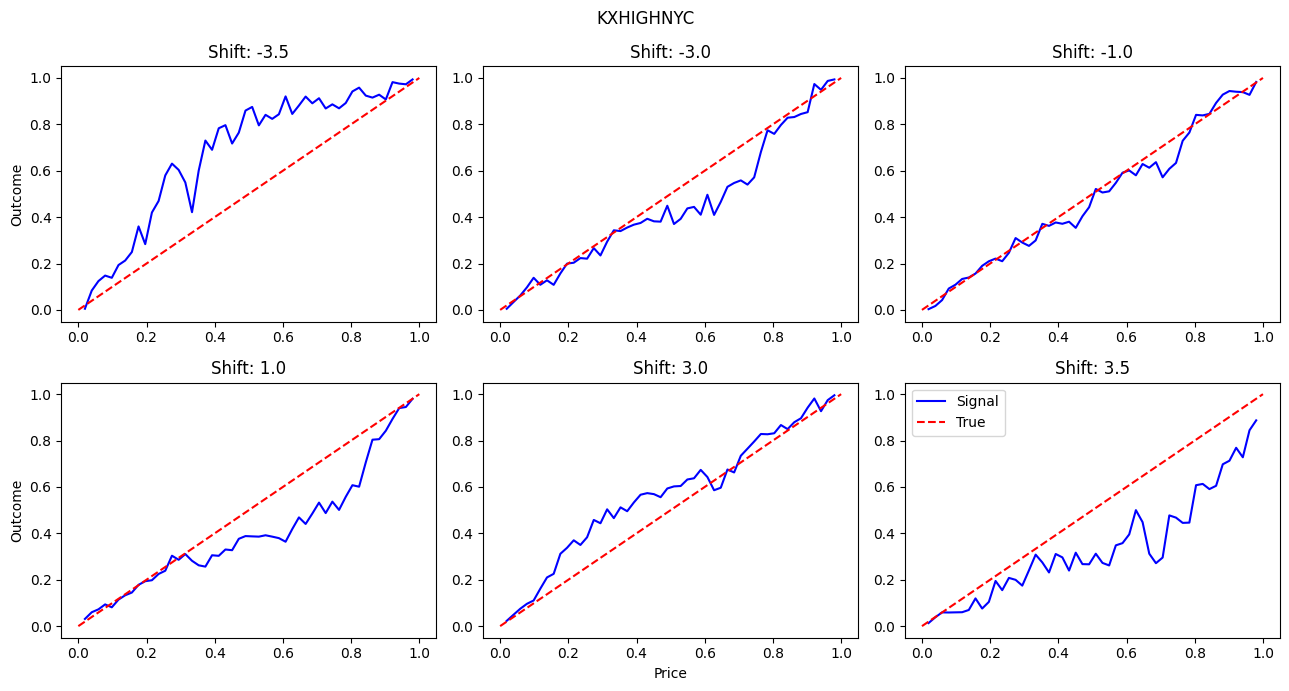

In [49]:
plot_price_curve(nyc_full_df, "KXHIGHNYC")

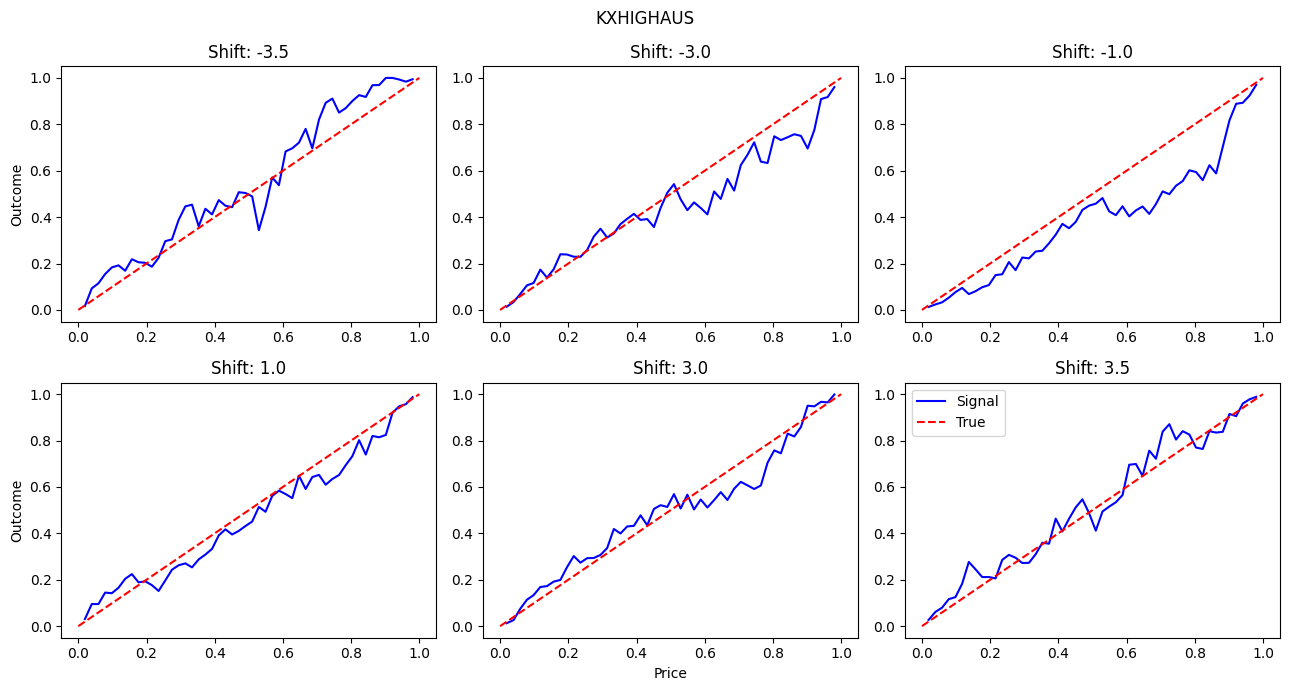

In [50]:
plot_price_curve(aus_full_df, "KXHIGHAUS")

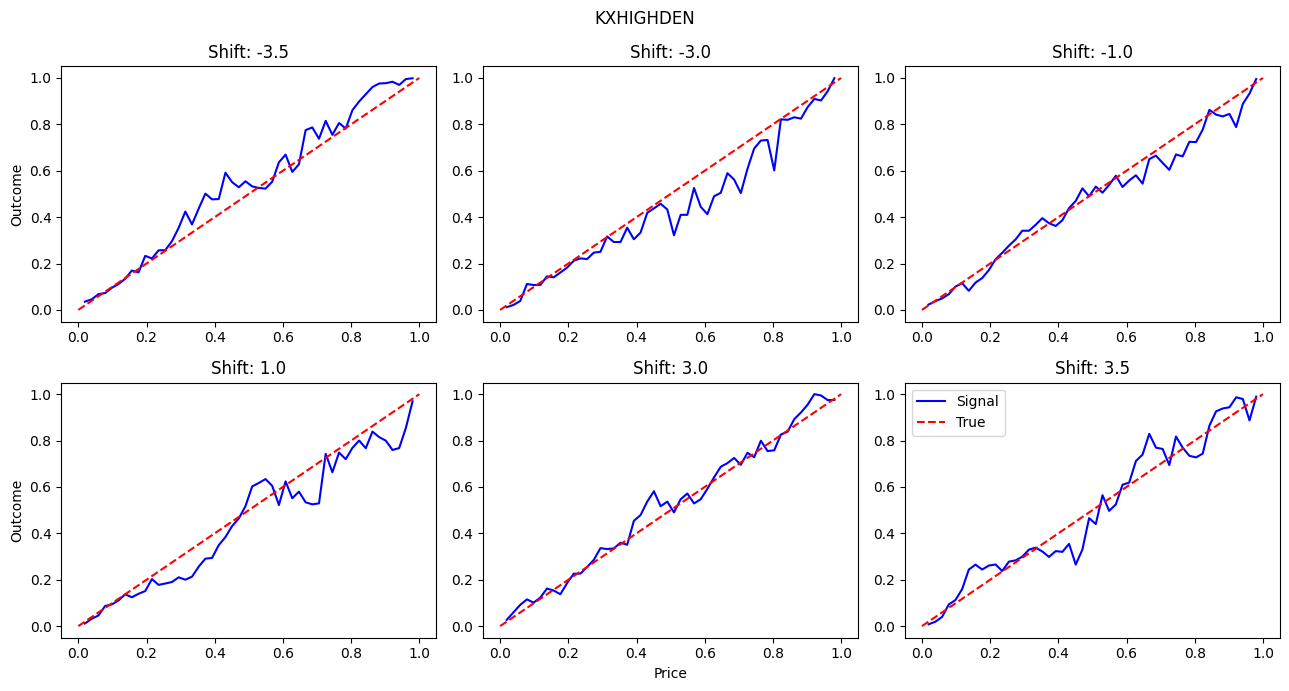

In [51]:
plot_price_curve(den_full_df, "KXHIGHDEN")

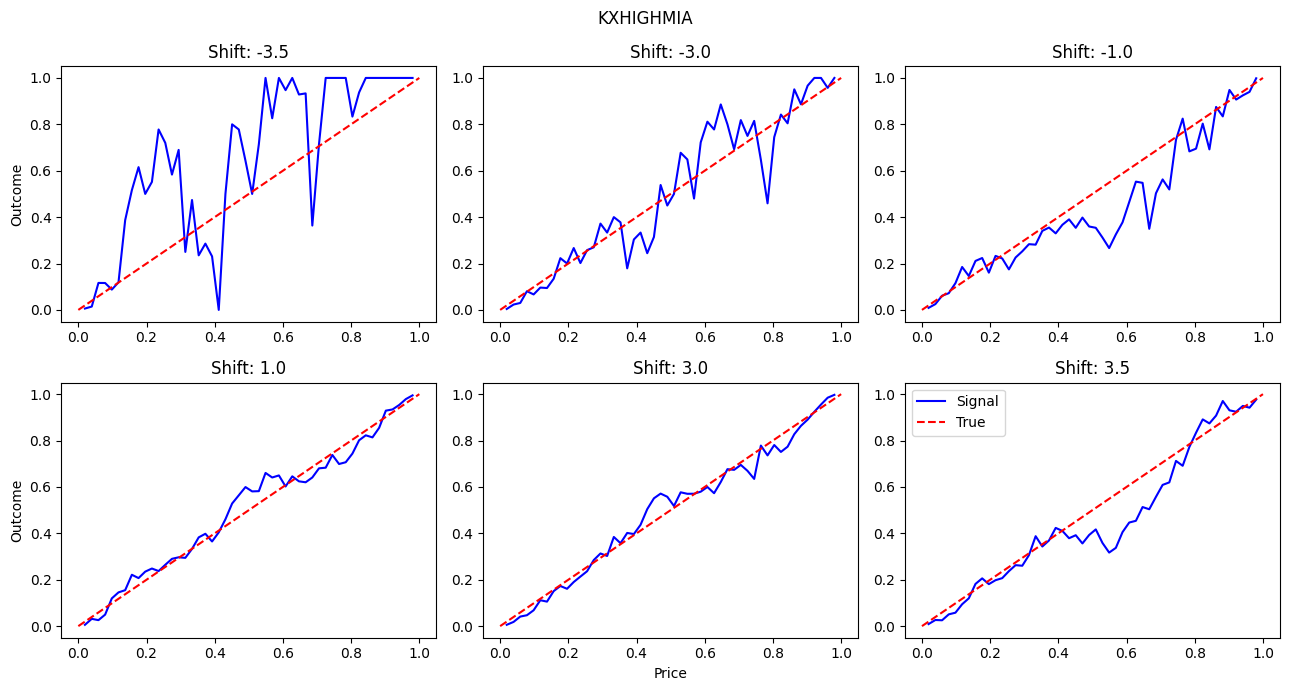

In [52]:
plot_price_curve(mia_full_df, "KXHIGHMIA")

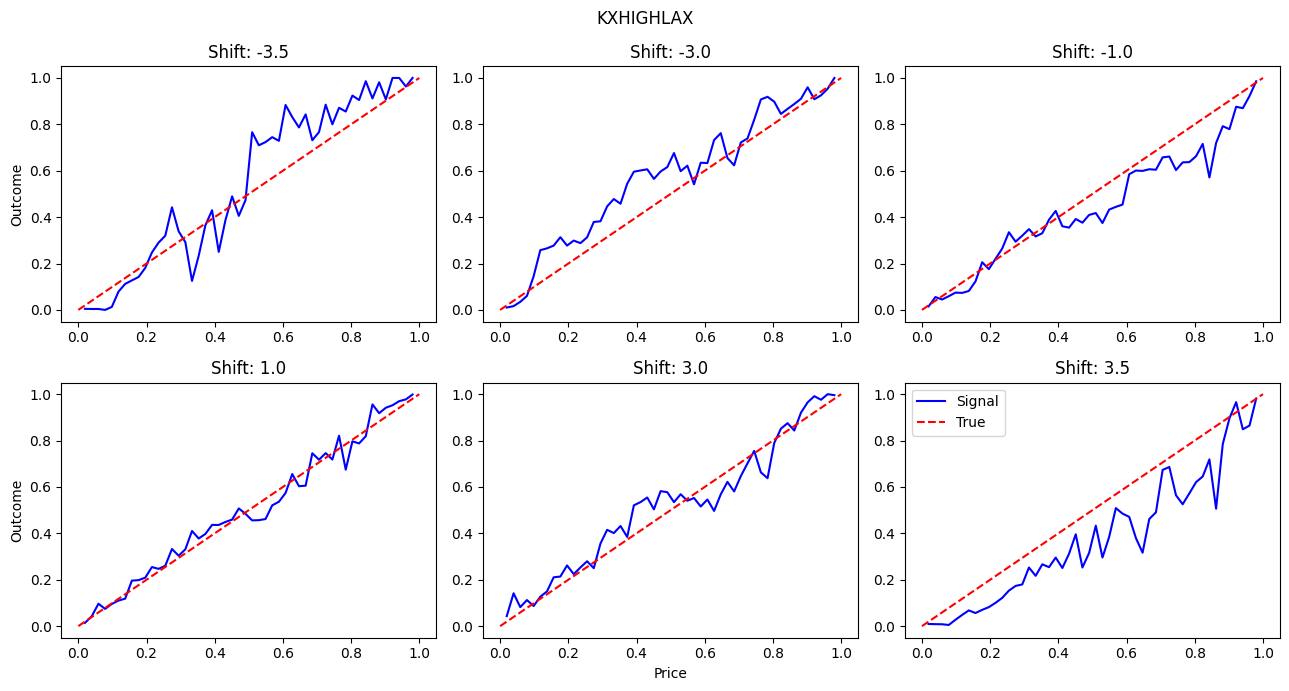

In [53]:
plot_price_curve(lax_full_df, "KXHIGHLAX")

In [ ]:
plot_price_curve(, "KXHIGHLAX")

In [141]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Lasso, LinearRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, VotingRegressor
from sklearn.naive_bayes import GaussianNB
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer

features = [
    'kalshi_strike_delta',
    'kalshi_forecast_delta',
    'forecast_strike_delta',
    "time_to_strike",
    # "entropy",
    # "shift",
    'yes_price',
    # "yes_trend",
]

def get_curve(daily_df, n_neighbors=100, test_size=0.25, features=features, p=2, weights='distance'):
    dates = sorted(list(daily_df.keys()))
    test_dates, train_dates = (
        dates[-int(test_size * len(dates)):], 
        dates[:-int(test_size * len(dates))]
    )

    train_df = pd.concat([daily_df[date] for date in train_dates])

    shifts = sorted(train_df['shift'].unique())
    pred_df = {
        'proba': [],
        'outcome': [],
        'yes_price': [],
        'shift': [],
        'yes_price': [],
    }

  

    pipelines = {
        shift: Pipeline(
            steps=[
                ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                ('scaler', RobustScaler(unit_variance=True)),
                # ('power', PowerTransformer()),
                ('voting', VotingClassifier(
                    estimators=[
                        # ('knn', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)),
                        ('lr', LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')),
                        # ('gbm', GradientBoostingClassifier(n_estimators=10, max_depth=3)),
                    ],
                    voting='soft'
                ))
                # ('voting', VotingRegressor(
                #     estimators=[
                #         ('lasso', Lasso(alpha=0.1)),
                #         # ('lr', LinearRegression()),
                #     ],
                #     # voting='hard'
                # ))
            ]
        )
        for shift in shifts
    }

    knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)

    for date in tqdm(test_dates):
        test_df = daily_df[date]
        for shift in shifts:

            train_shift_df = train_df[train_df['shift'] == shift]
            test_shift_df = test_df[test_df['shift'] == shift]

            # knn.fit(train_shift_df[features], train_shift_df["outcome"].values)
            # y_train = knn.predict_proba(train_shift_df[features])[:, 1]

            if len(test_shift_df) == 0:
                continue

            pipelines[shift].fit(train_shift_df[features], train_shift_df["outcome"].values)
            prob = pipelines[shift].predict_proba(test_shift_df[features])[:, 1]

            pred_df['proba'].extend(prob)
            pred_df['outcome'].extend(test_shift_df["outcome"].values)
            pred_df['shift'].extend(test_shift_df["shift"].values)
            pred_df['yes_price'].extend(test_shift_df["yes_price"].values)

        train_df = pd.concat([train_df, test_df])
    return pd.DataFrame(pred_df)

In [142]:
def plot_price_curve(df, ticker, buckets=25):
    bins = np.arange(0, 1 + 1 / buckets, 1 / buckets)
    df['price'] = df['yes_price'] / 100
    df['price_buckets'] = pd.cut(
        df['price'], 
        bins, 
        include_lowest=True
    )
    df['proba_buckets'] = pd.cut(
        df['proba'], 
        bins, 
        include_lowest=True
    )
    shifts = sorted(df['shift'].unique())
    price_curve = df.groupby(['shift', 'price_buckets'])['outcome'].mean()
    proba_curve = df.groupby(['shift', 'proba_buckets'])['outcome'].mean()

    x_values = np.array([l + bins[1] / 2 for l in bins[:-1]])

    fig, ax = plt.subplots(2, 3, figsize=(13, 7))
    for i, shift in enumerate(shifts):
        price_data = price_curve[shift]
        proba_data = proba_curve[shift]
        n_points = len(df[df['shift'] == shift])

        price_error = (price_data - x_values) ** 2
        proba_error = (proba_data - x_values) ** 2

        edge = price_error - proba_error

        if shift < 0:
            ax[0, i].plot(x_values, price_data, color='blue', label='Price')
            ax[0, i].plot(x_values, proba_data, color='green', label='Proba')
            ax[0, i].plot([0, 1], [0, 1], color='red', linestyle='--', label='True')
            ax[0, i].set_title(f'Shift: {shift} | N = {n_points} | Edge = {edge.mean():.3f}.')
        else:
            ax[1, i - 3].plot(x_values, price_data, color='blue', label='Price')
            ax[1, i - 3].plot(x_values, proba_data, color='green', label='Proba')
            ax[1, i - 3].plot([0, 1], [0, 1], color='red', linestyle='--', label='True')
            ax[1, i - 3].set_title(f'Shift: {shift} | N = {n_points} | Edge = {edge.mean():.3f}.')
    ax[0, 0].set_ylabel('Outcome')
    ax[1, 0].set_ylabel('Outcome')
    ax[1, 1].set_xlabel('Price')
    plt.suptitle(ticker)
    plt.legend()
    plt.tight_layout()
    plt.show()

100%|██████████| 74/74 [13:18<00:00, 10.79s/it]


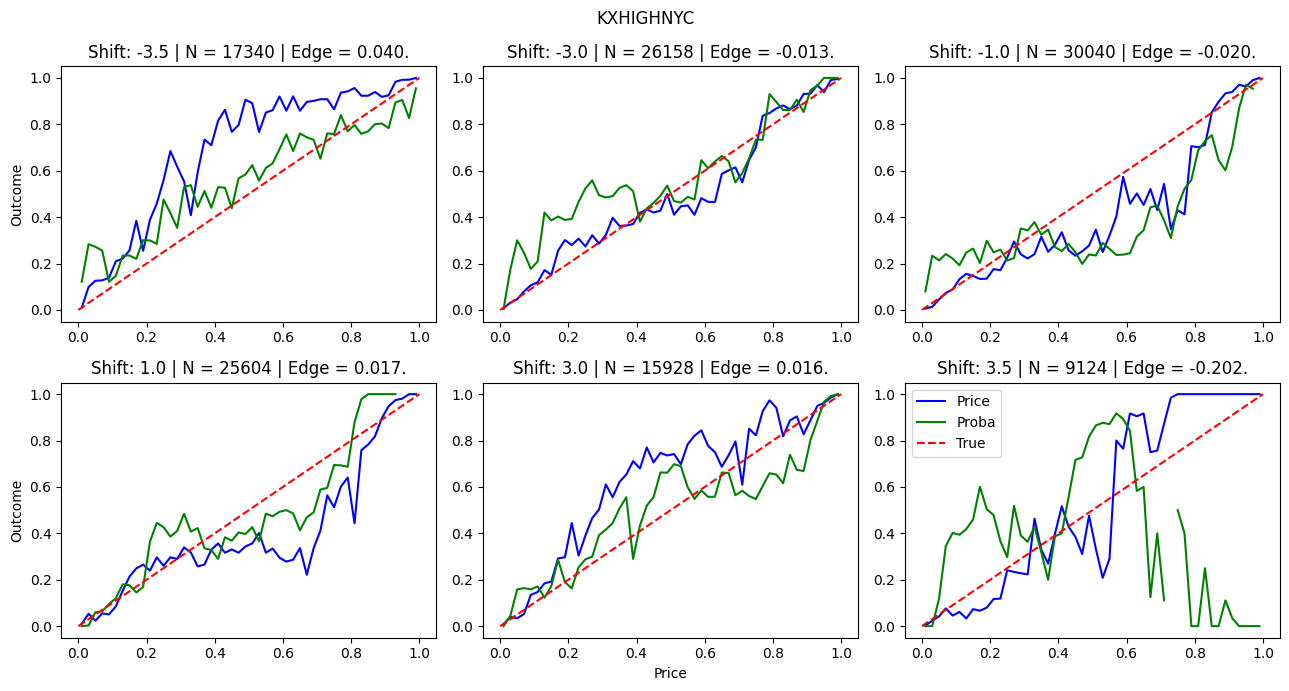

In [143]:
nyc_curve_df = get_curve(nyc_daily_df, n_neighbors=250, test_size=0.25, features=features, p=2, weights='distance')
plot_price_curve(nyc_curve_df, "KXHIGHNYC", buckets=50)

100%|██████████| 75/75 [00:24<00:00,  3.01it/s]


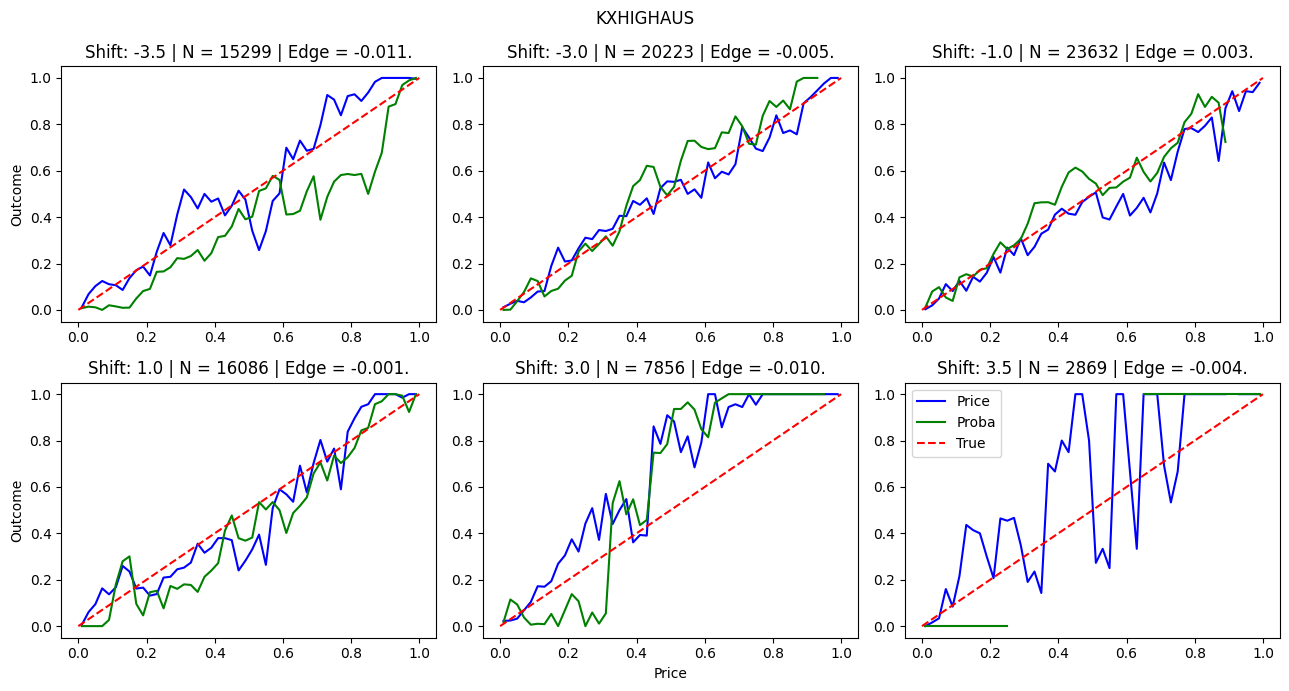

In [134]:
aus_curve_df = get_curve(aus_daily_df, n_neighbors=125, test_size=0.25, features=features, p=2, weights='distance')
plot_price_curve(aus_curve_df, "KXHIGHAUS", buckets=50)

100%|██████████| 38/38 [00:01<00:00, 22.08it/s]


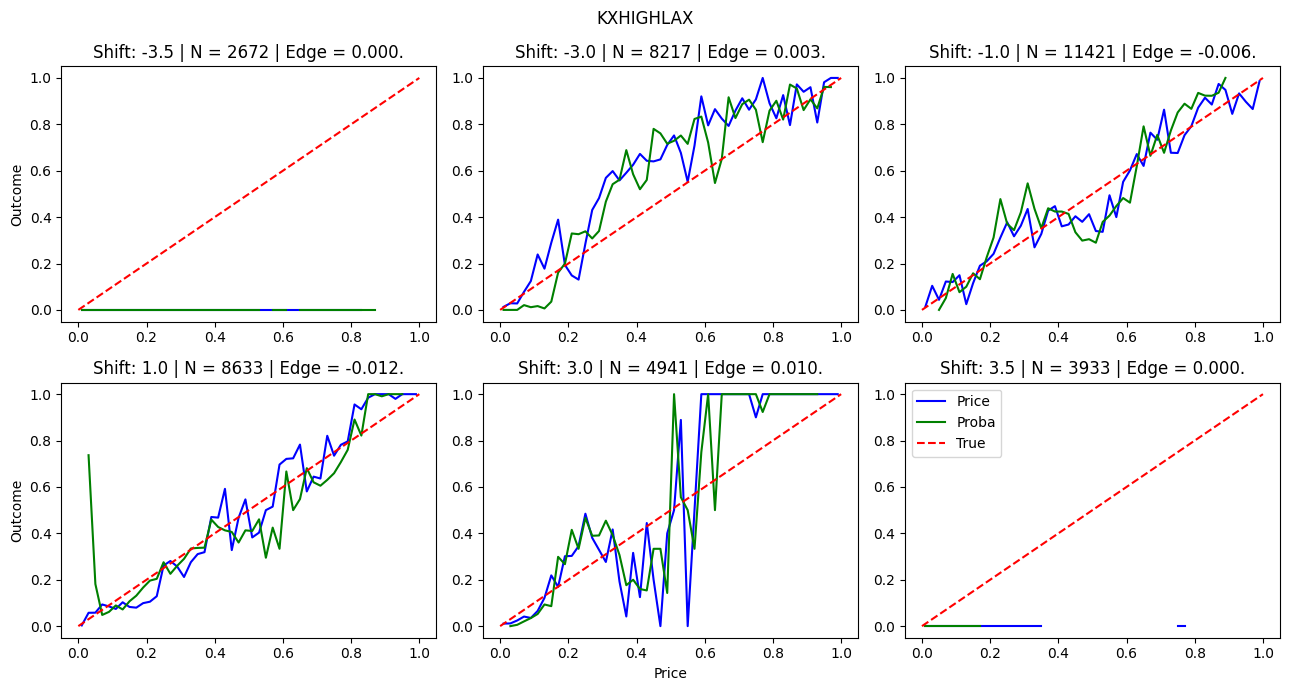

In [130]:
lax_curve_df = get_curve(lax_daily_df, n_neighbors=125, test_size=0.25, features=features, p=2, weights='distance')
plot_price_curve(lax_curve_df, "KXHIGHLAX", buckets=50)

100%|██████████| 75/75 [00:23<00:00,  3.14it/s]


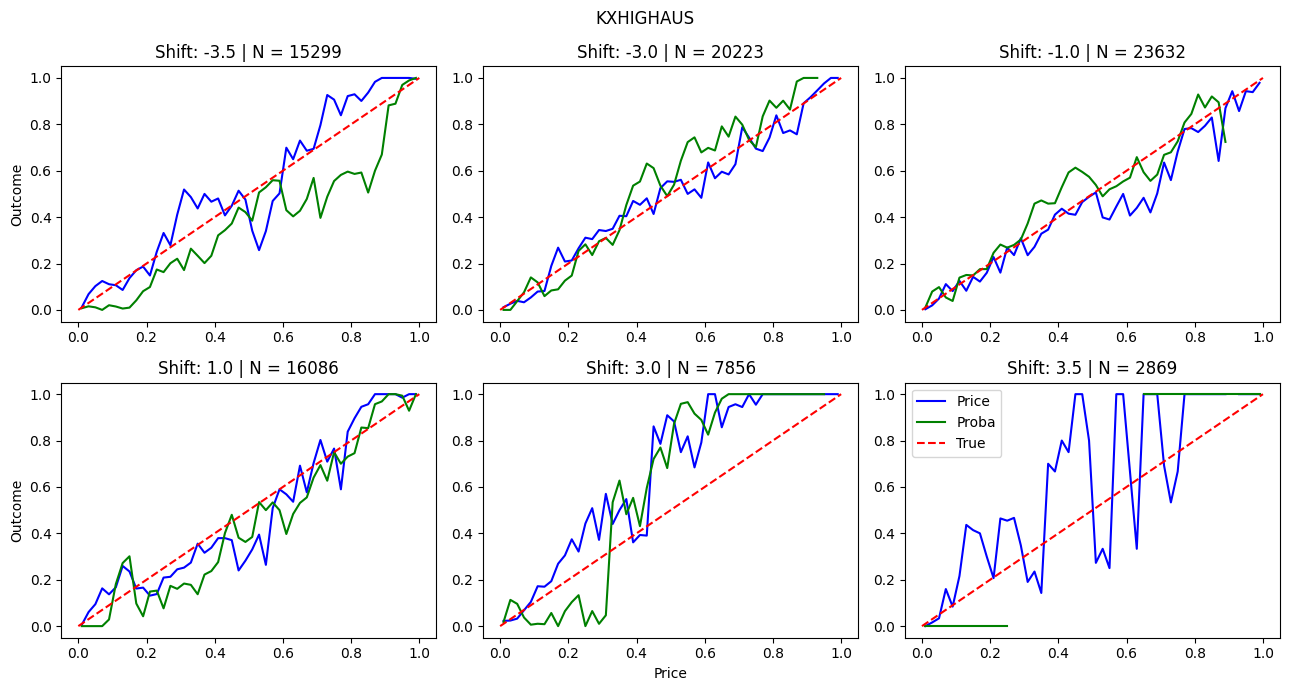

In [98]:
aus_curve_df = get_curve(aus_daily_df, n_neighbors=125, test_size=0.25, features=features, p=2, weights='distance')
plot_price_curve(aus_curve_df, "KXHIGHAUS", buckets=50)

100%|██████████| 75/75 [00:05<00:00, 13.79it/s]


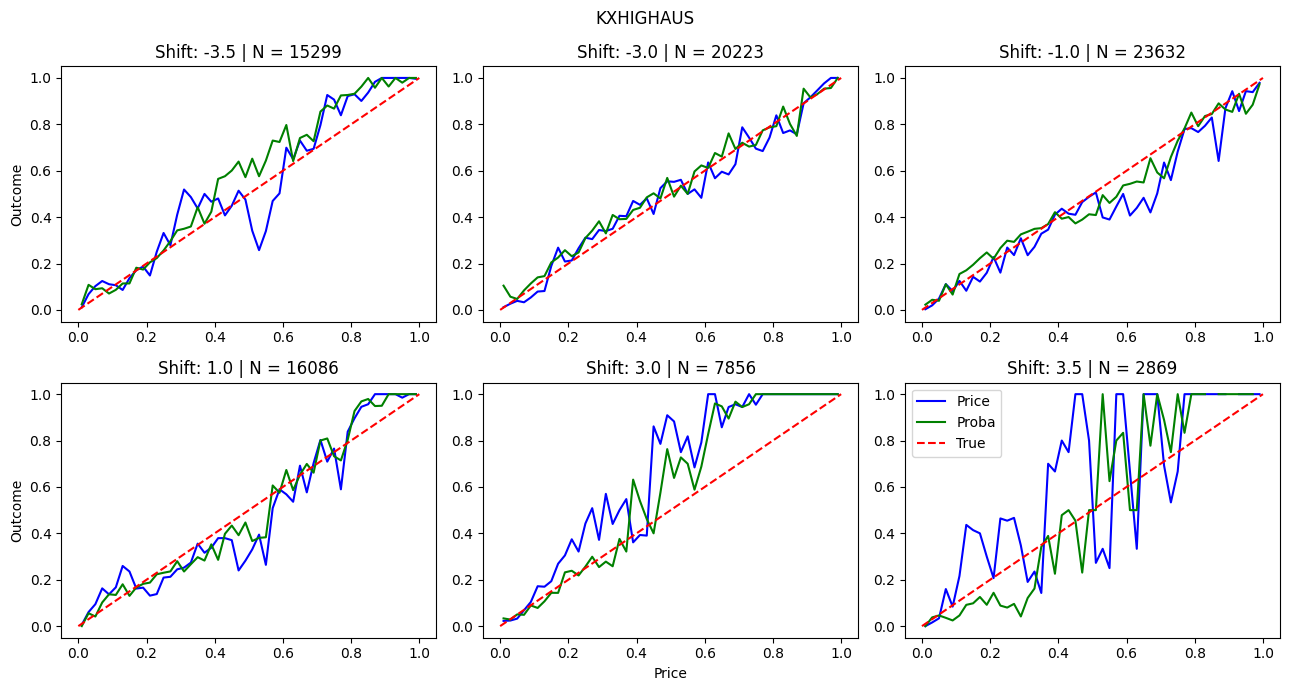

In [54]:
aus_curve_df = get_curve(aus_daily_df, n_neighbors=100, test_size=0.25, features=features, p=2, weights='distance')
plot_price_curve(aus_curve_df, "KXHIGHAUS", buckets=50)

100%|██████████| 38/38 [00:01<00:00, 31.22it/s]


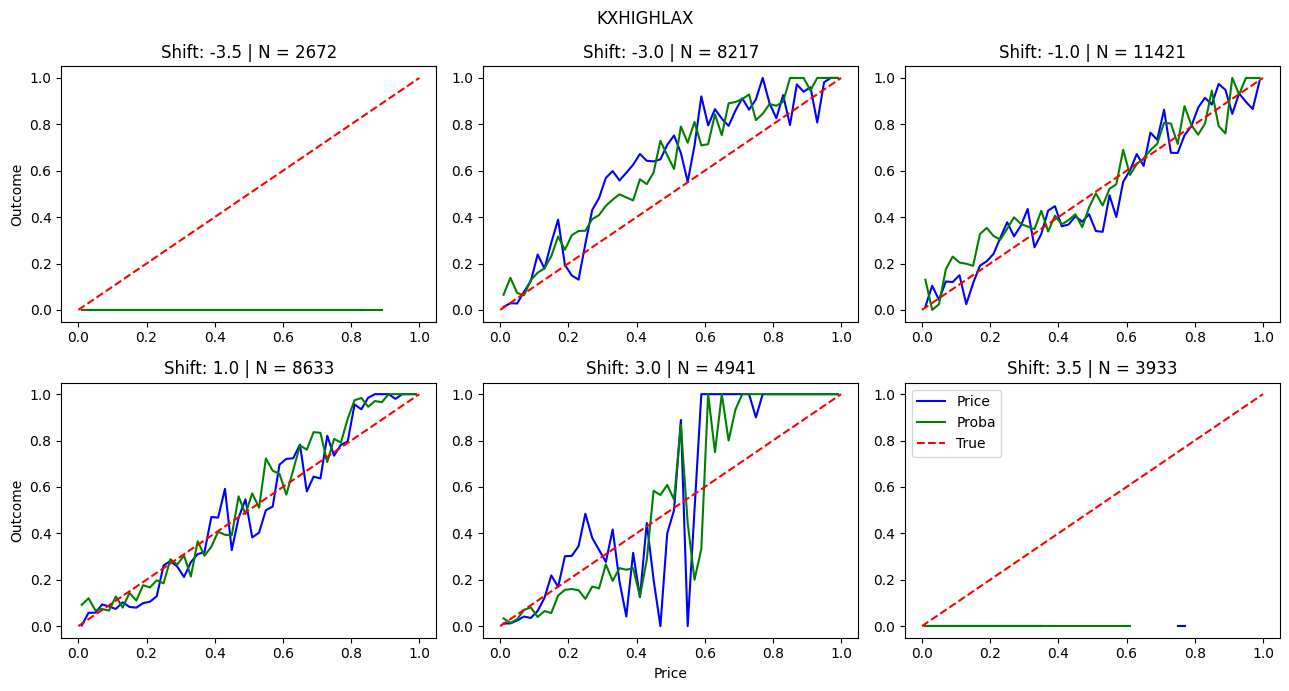

In [55]:
lax_curve_df = get_curve(lax_daily_df, n_neighbors=100, test_size=0.25, features=features, p=2, weights='distance')
plot_price_curve(lax_curve_df, "KXHIGHLAX", buckets=50)

100%|██████████| 74/74 [00:03<00:00, 22.71it/s]


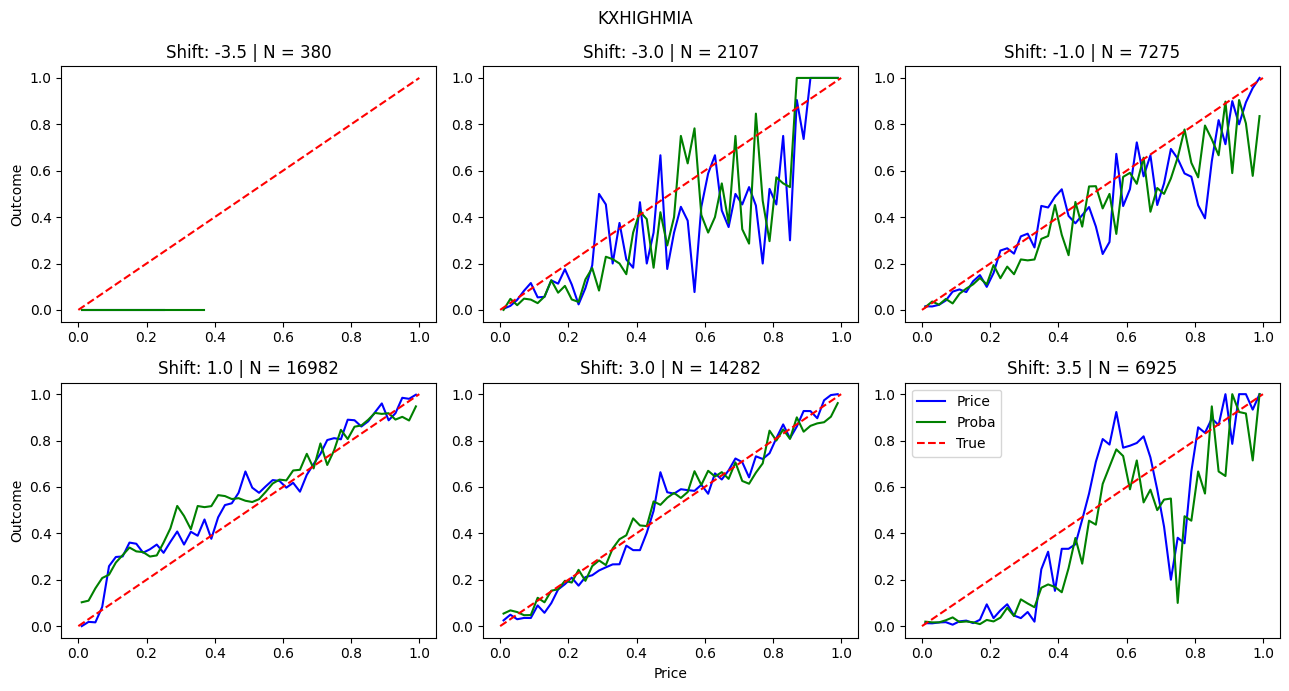

In [56]:
mia_curve_df = get_curve(mia_daily_df, n_neighbors=100, test_size=0.25, features=features, p=2, weights='distance')
plot_price_curve(mia_curve_df, "KXHIGHMIA", buckets=50)

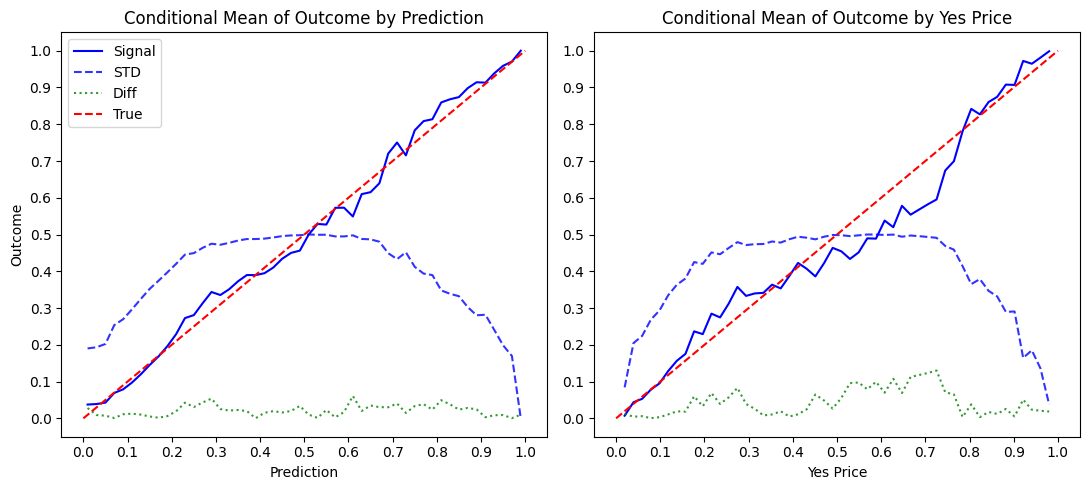

0.021015128833490895 0.04420275376206969


In [14]:
n_buckets = 50

pred_df['pred_buckets'] = pd.cut(pred_df['prediction'], n_buckets)
pred_conditional_mean = pred_df.groupby('pred_buckets')['outcome'].mean()
pred_conditional_std = pred_df.groupby('pred_buckets')['outcome'].std() 
pred_x_values = np.array([(x.left + x.right) / 2 for x in pred_conditional_mean.index.values])
pred_diff = pred_conditional_mean.values - pred_x_values

pred_df['price_buckets'] = pd.cut(pred_df['yes_price'], n_buckets)
price_conditional_mean = pred_df.groupby('price_buckets')['outcome'].mean()
price_conditional_std = pred_df.groupby('price_buckets')['outcome'].std() 
price_x_values = np.array([(x.left + x.right) / 200 for x in price_conditional_mean.index.values])
price_diff = price_conditional_mean.values - price_x_values

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0].plot(
    pred_x_values, 
    pred_conditional_mean.values,
    color = 'blue',
    label = 'Signal'
)
ax[0].plot(
    pred_x_values, 
    pred_conditional_std.values,
    color = 'blue',
    linestyle = '--',
    label = 'STD',
    alpha = 0.8
)
ax[0].plot(
    pred_x_values, 
    abs(pred_diff),
    color = 'green',
    linestyle = ':',
    label = 'Diff',
    alpha = 0.8
)
ax[0].set_xticks(np.arange(0, 1.1, 0.1))
ax[0].set_yticks(np.arange(0, 1.1, 0.1))
ax[0].plot([0, 1], [0, 1], color='red', linestyle='--', label='True')
ax[0].set_xlabel('Prediction')  
ax[0].set_ylabel('Outcome')
ax[0].set_title('Conditional Mean of Outcome by Prediction')

ax[1].plot(
    price_x_values, 
    price_conditional_mean.values,
    color = 'blue'
)
ax[1].plot(
    price_x_values, 
    price_conditional_std.values,
    color = 'blue',
    linestyle = '--',
    label = 'STD',
    alpha = 0.8
)
ax[1].plot(
    price_x_values, 
    abs(price_diff),
    color = 'green',
    linestyle = ':',
    label = 'Diff',
    alpha = 0.8
)
ax[1].set_xticks(np.arange(0, 1.1, 0.1))
ax[1].set_yticks(np.arange(0, 1.1, 0.1))
ax[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='True')
ax[1].set_xlabel('Yes Price')
ax[1].set_title('Conditional Mean of Outcome by Yes Price')

ax[0].legend()
plt.tight_layout()
plt.show()

print(abs(pred_diff).mean(), abs(price_diff).mean())

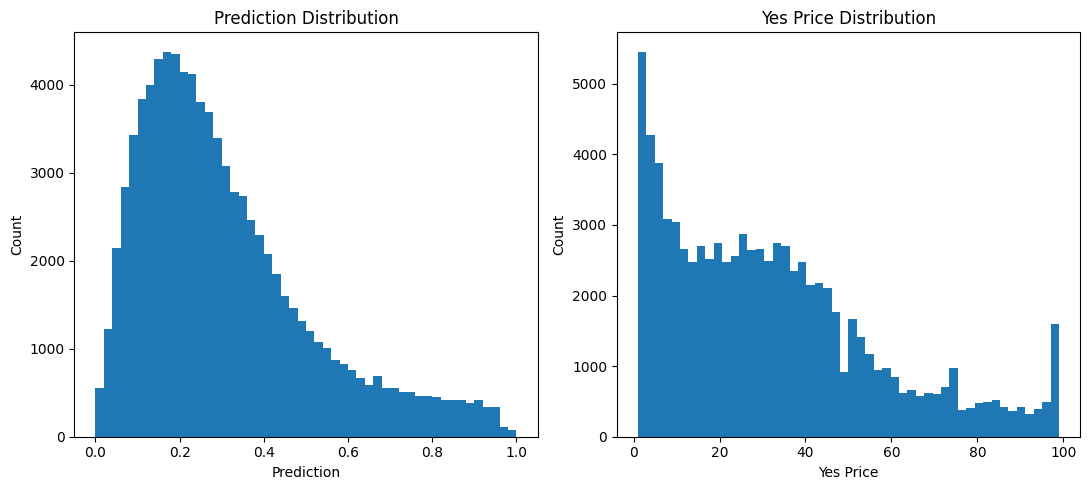

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0].hist(pred_df['prediction'], bins=50)
ax[0].set_xlabel('Prediction')
ax[0].set_ylabel('Count')
ax[0].set_title('Prediction Distribution')

ax[1].hist(pred_df['yes_price'], bins=50)
ax[1].set_xlabel('Yes Price')
ax[1].set_ylabel('Count')
ax[1].set_title('Yes Price Distribution')

plt.tight_layout()
plt.show()